# Filter Audit Viz

Loads `output/eval/` data, builds a `{value: color}` map and renders graphs:

| Audit | Metric | Visualization | Description |
| :--- | :--- | :--- | :--- |
| 1 | PR | table | Pearson's *r* |
| 1 |  PMI | bar graphs | pointwise mutual information |
| 1 | DV | Line series | data volume |
| 1 | RR | Sankey, line series | retention rate |
| 1 | LRP | stacked bars, waterfall | log-retention penalty |


In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

## Load data

In [2]:
OUTPUT_DIR = Path("../output/eval")
PMI_PATH = OUTPUT_DIR / "pmi"
SANKEY_PATH = OUTPUT_DIR / "retention/sankeys.json"
PLOT_PATH = OUTPUT_DIR / "retention/plot_data"

pmi_data = {
    p.stem: pd.read_csv(p)
    for p in sorted(PMI_PATH.glob("*.csv"))
}

with open(SANKEY_PATH) as f:
    sankeys = json.load(f)

series = {
    p.stem.replace("retention_", ""): pd.read_csv(p, dtype={"value": str})
    for p in sorted(PLOT_PATH.glob("retention_*.csv"))
}

## Color map

In [3]:
PALETTE = px.colors.qualitative.Set3
EXCLUDED_COLOR = "rgba(150,150,150,0.55)"

all_values = set()
for df in series.values():
    color_keys = [k.split(" / ")[0] for k in df["value"].unique()]
    
    all_values |= set(color_keys)
all_values.discard("total")
all_values = sorted(all_values)

COLOR_MAP = {v: PALETTE[i % len(PALETTE)] for i, v in enumerate(all_values)}

print(f"{len(COLOR_MAP)} values colored")
# COLOR_MAP

38 values colored


# Correlation with CMI score

*Operationalized hypothesis*: document CMI score (continuous \[0, 1\]) is positively correlated with document exclusion (binary 0/1).

For document exclusion after the full pipeline, results are **null**. There is close to zero correlation between CMI score and document exclusion in this scenario.

For document exclusion after only the first filter (language identification), the results are **positive**. There is weak to moderate correlation between CMI score and document exclusion in this case. 

This does make sense because several of the deterministic filters are oriented toward document character ratios and repetition; LinCE documents are individual social media posts that do not follow the same orthographic norms as more formal/traditional registers. While LinCE documents are general shorter (TODO: report token averages per source/component), token count does not correlate with document exclusion.

In [ ]:
# Copied directly from eval.correlation console output
cmi_correlation = {
    "pipeline": {
        "corr": 0.0053,
        "p_value": 0.0268
    },
    "lang_id": {
        "corr": 0.3041,
        "p_value": 0.0
    }
}

token_correlation = {
    "pipeline": {
        "corr": -0.12,
        "p_value": 0.0
    },
    "lang_id": {
        "corr": 0.05,
        "p_value": 0.0
    },
}
cmi_df = pd.DataFrame.from_dict(cmi_correlation, orient='index')
token_df = pd.DataFrame.from_dict(token_correlation, orient='index')

In [ ]:
print(cmi_df.to_latex())

# Pointwise Mutual Information

*Operationalized hypothesis*: PMI(document feature value; document exclusion) will trend with LEU centrality/peripherality (as represented by cluster ID). 

These specific results are **negative**: PMI for cluster IDs and source corpora are close to zero, indicating independence between document exclusion and this representation of dialect typology when computed in isolation. While there are stronger results for document genres, the scale is compressed when normalized. 

The strongest results in fact are for the feature combinations. One of the strongest **positive** associations with document exclusion is for ICE documents in the spoken modality -- this subset is in fact more strongly associated with localized/dialectal features! 

Interestingly, ICE documents trend by cluster and genre, with the most avoidance of exclusion by cluster centrality and written modality.

In [ ]:
series.keys()

In [4]:
def render_pmi_bar(subset_key, color_map=COLOR_MAP, width=600, height=400, font_size=11):
    df = pmi_data[subset_key]
    fig = px.bar(
        df, 
        x="pmi", 
        y="feature_value", 
        orientation="h", 
        color="feature_value",
        color_discrete_map=color_map,
        title=f"PMI({subset_key.replace("by_", "")} value; document excluded)"
    )
    fig.update_layout(showlegend=False, height=height, width=width, font=dict(size=font_size))

    x_min = min(-0.1, df.pmi.min() - 0.1)
    x_max = max(0.1, df.pmi.max() + 0.1)
    fig.update_xaxes(range=[x_min, x_max])
    return fig

def render_npmi_bar(subset_key, color_map=COLOR_MAP, width=600, height=400, font_size=11):
    df = pmi_data[subset_key]
    fig = px.bar(
        df, 
        x="npmi", 
        y="feature_value", 
        orientation="h", 
        color="feature_value",
        color_discrete_map=color_map,
        title=f"PMI({subset_key.replace("by_", "")} value; document excluded)"
    )
    x_min = min(-0.1, df.npmi.min() - 0.1)
    x_max = max(0.1, df.npmi.max() + 0.1)
    fig.update_xaxes(range=[x_min, x_max])
    fig.update_layout(showlegend=False, height=height, width=width, font=dict(size=font_size))
    return fig

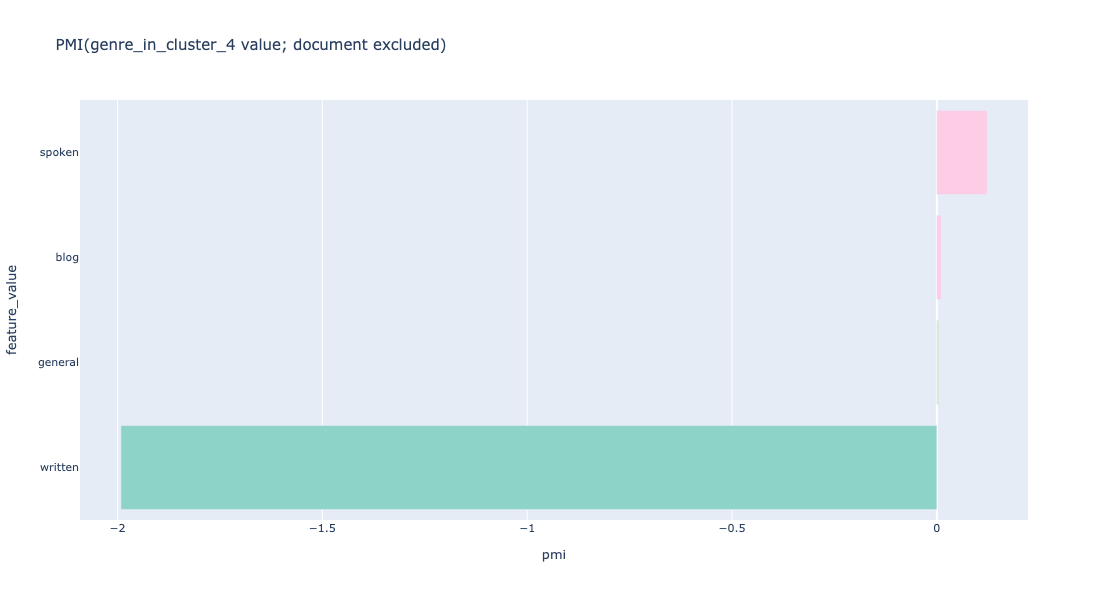

In [5]:
# for key, data in pmi_data.items():
#     render_pmi_bar(key, data).show()
render_pmi_bar("by_genre_in_cluster_4", height=600)

## Data Volume

*Operationalized hypothesis*: Cluster 1 will retain the most data and LEU centrality/peripherality will trend with volume retention.

The results are **positive**: Cluster 1 indeed retains the most volume throughout the stages of filtering. Surprisingly, the delta between cluster volumes sharply declines after FineWeb quality filter is applied, which shows the strength of filters blindly predicated on document length or punctuation character ratios.

In [6]:
def render_volume_line(subset_key, color_map=COLOR_MAP,height=600,width=400, font_size=11):
    df = series[subset_key]
    fig = px.line(
        df, x="stage", y="included", color="value",
        color_discrete_map=color_map, markers=True,
        title=f"Absolute volume by stage: {subset_key}",
    )
    fig.update_layout(width=width, height=height, yaxis_title="records_remaining", font=dict(size=font_size))
    # fig.update_xaxes(range=[0.9,5.1], dtick=1)
    return fig

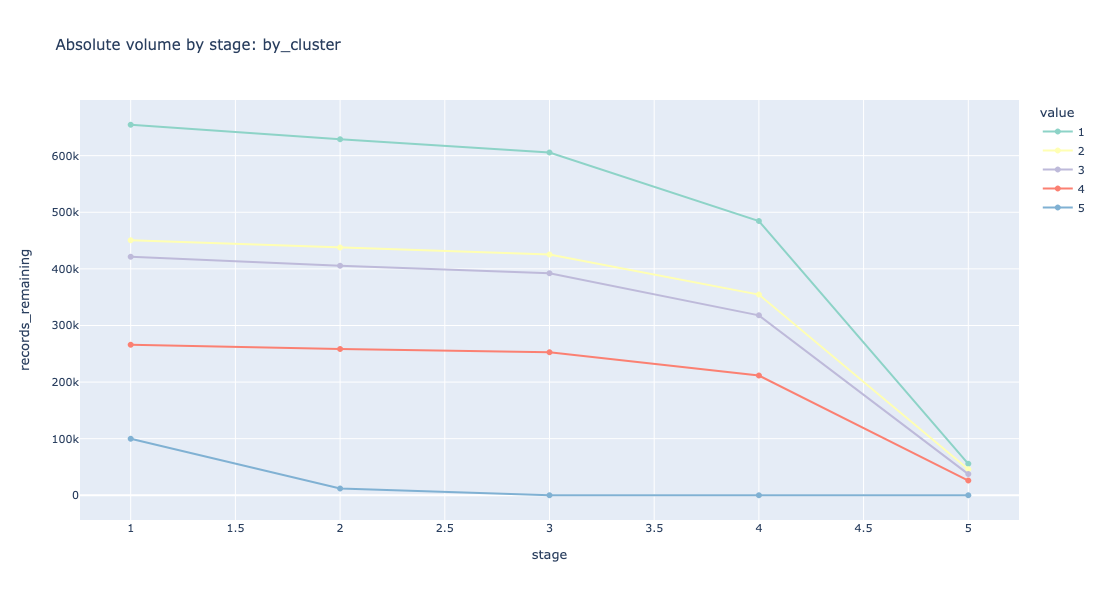

In [7]:
render_volume_line("by_cluster")

In [8]:
def compute_relative_rate(subset_key, base_key):
    data = series[subset_key]
    base_data = data.loc[data.value == base_key]
    
    base_data["excluded"] = base_data.total - base_data.included
    total_excluded = base_data.excluded.sum()
    total_stage_1 = base_data.loc[base_data.stage == 1, "total"].values[0]

    base_rate = total_excluded / total_stage_1
    for val, df in series[subset_key].groupby("value"):
        print(val)
        df["excluded"] = df.total - df.included
        total_excluded = df.excluded.sum()
        total_stage_1 = df.loc[df.stage == 1, "total"].values[0]
    
        result = total_excluded / total_stage_1
        print("Removal rate: ", result)
        print(f"Removal relative to {base_key}: ", result / base_rate)

In [9]:
compute_relative_rate("by_component_genre", "us / written")

au / blog
Removal rate:  0.7959401937926461
Removal relative to us / written:  9.364002279913484
au / general
Removal rate:  0.9117009153402198
Removal relative to us / written:  10.725893121649644
au / spoken
Removal rate:  0.9933333333333333
Removal relative to us / written:  11.686274509803921
au / written
Removal rate:  0.16080402010050251
Removal relative to us / written:  1.8918120011823825
bd / blog
Removal rate:  0.9260250810201494
Removal relative to us / written:  10.894412717884109
bd / general
Removal rate:  0.9139980513153622
Removal relative to us / written:  10.752918250768966
ca / blog
Removal rate:  0.9096561678818609
Removal relative to us / written:  10.701837269198363
ca / general
Removal rate:  0.9122796263148861
Removal relative to us / written:  10.732701486057483
ca / spoken
Removal rate:  1.0
Removal relative to us / written:  11.76470588235294
ca / written
Removal rate:  0.095
Removal relative to us / written:  1.1176470588235294
gb / blog
Removal rate:  0.909

# Retention Rate (RR) and Log-Retention Penalty (LRP)
*Operationalized hypothesis*: Cluster 1 will have the highest retention rate at each stage of the pipeline. 

The results are basically **negative**: all clusters except for code-switching share nearly identical relative retention rates. This is mostly due to the volume of GloWbe data obscuring the effects *within* clusters. See results for `by_cluster_in_ice` compared to `by_cluster_in_glowbe`, or `by_genre_in_cluster_*`.

Also note that the retention rate for LinCE at stage 5 of the pipeline is highly inflated but only accounts for 48 out of 68 input documents (from a set of originally 172K documents).

## Line Charts

In [10]:
def render_retention_line(subset_key, color_map=COLOR_MAP,height=600,width=400, font_size=11):
    df = series[subset_key]
    fig = px.line(
        df, x="stage", y="retention", color="value",
        color_discrete_map=color_map, markers=True,
        title=f"Retention by stage: {subset_key}"
    )
    fig.update_layout(width=width, height=height, font=dict(size=font_size))
    fig.update_xaxes(range=[0.9,5.1], dtick=1)
    return fig

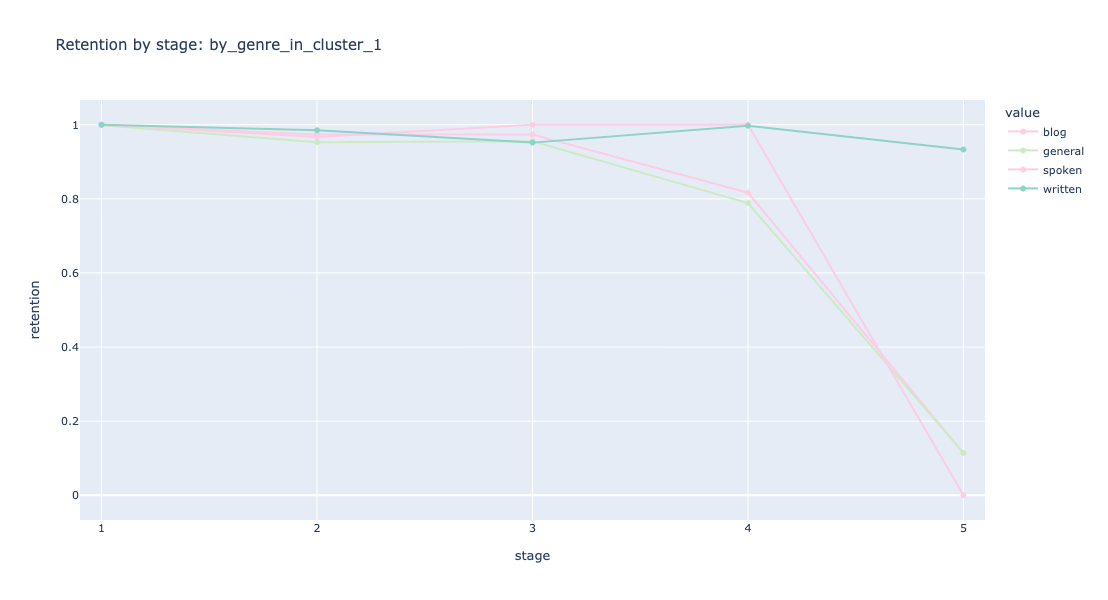

In [13]:
render_retention_line("by_genre_in_cluster_1", width=800)

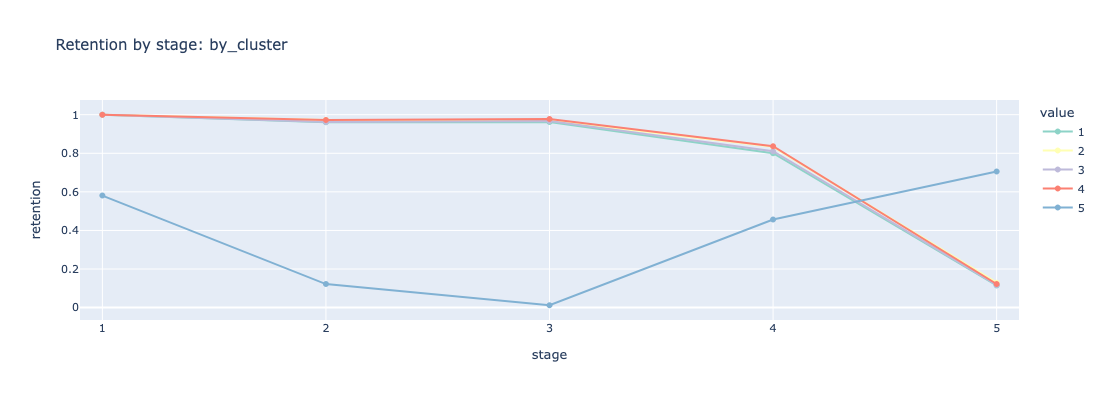

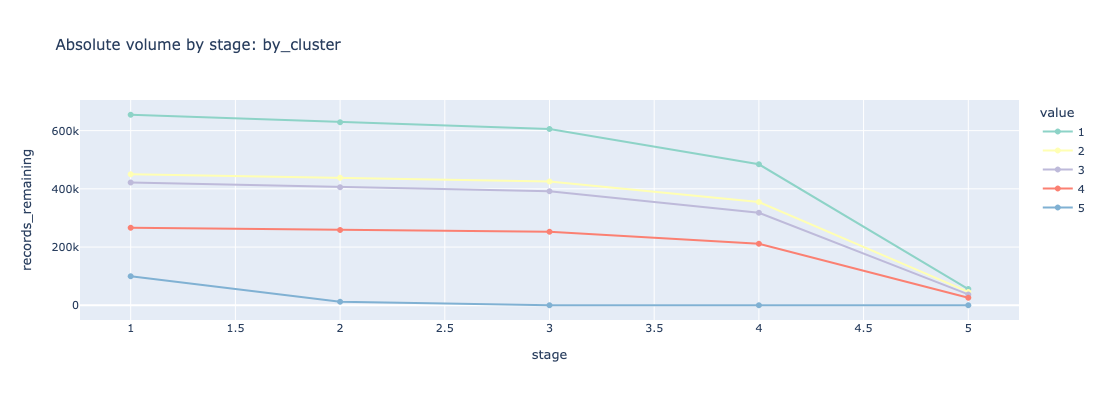

In [14]:
subset = "by_cluster"

# render_sankey(subset).show()
render_retention_line(subset, height=400).show()
render_volume_line(subset, height=400).show()

## Waterfall Chart


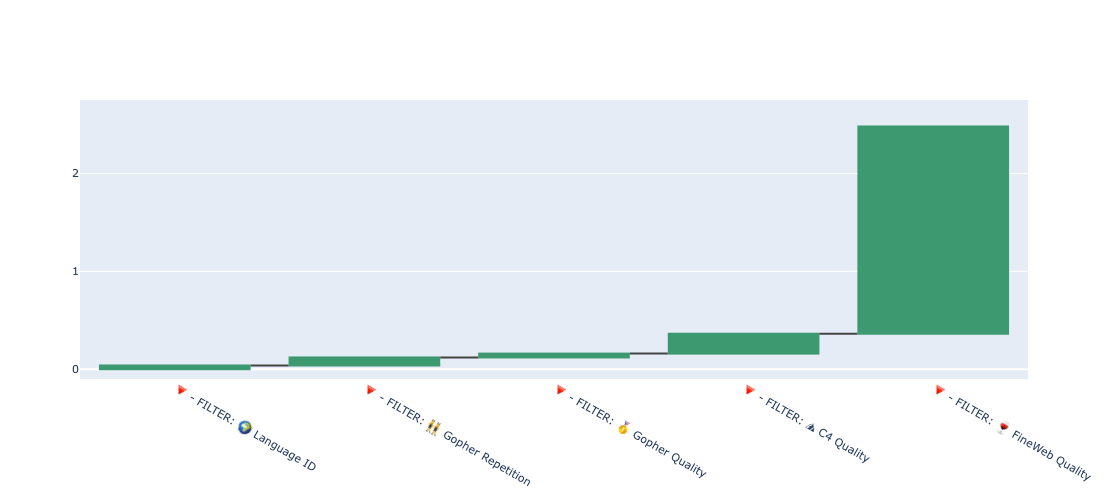

In [15]:
def render_lrp_contribution(subset_key, color_map=COLOR_MAP, width=600, height=400, font_size=11):
    df = series[subset_key]
    fig = go.Figure(go.Waterfall(
        orientation="v",
        x=df.stage_name,
        y=df.lrp    
    ))
    fig.update_yaxes(dtick=1, range=[-0.1,2.75])
    fig.update_layout(width=width, height=height, font=dict(size=font_size))
    return fig

render_lrp_contribution("overall", height=500)

## Stacked Bar Chart

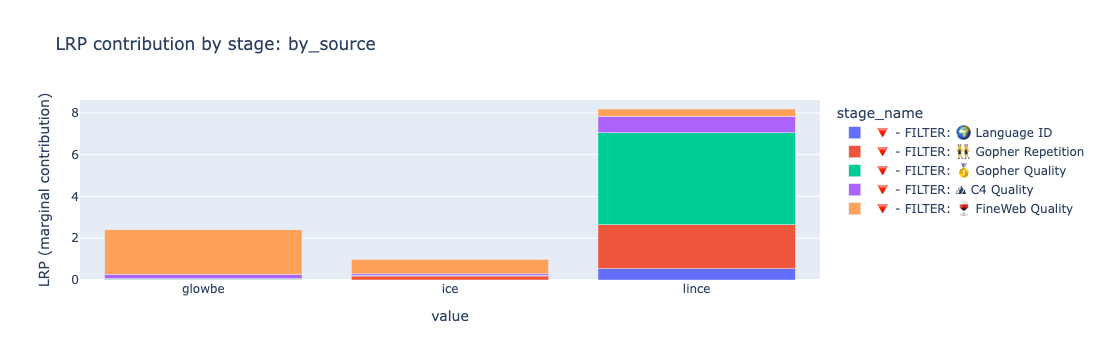

In [16]:
def render_lrp_contribution(subset_key):
    df = series[subset_key]
    fig = px.bar(
        df, x="value", y="lrp", color="stage_name",
        title=f"LRP contribution by stage: {subset_key}",
        labels={"lrp": "LRP (marginal contribution)"}
    )
    return fig

render_lrp_contribution("by_source")

## Render Sankey diagrams

In [ ]:
def render_sankey(subset_key, color_map=COLOR_MAP, width=1200, height=600, font_size=11):
    sd = sankeys[subset_key]
    node_colors = [
        EXCLUDED_COLOR if label == "" else color_map.get(value, "#999999")
        for label, value in zip(sd["node"]["label"], sd["node"]["customdata"])
    ]
    
    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node={**sd["node"], "color": node_colors},
        link=sd["link"]
    ))
    
    fig.update_layout(title=subset_key, width=width, height=height, font=dict(size=font_size))
    return fig

In [ ]:
render_sankey("for_1")